# Bot-IoT Version2 ALL Feature：分開分類 + 隨機森林independent vs Chained

本筆記本分成上下兩段：
1. 上半段：直接使用原始資料做隨機森林分類（不特別平衡）(Independent)
2. 下半段：直接使用原始資料做隨機森林分類（不特別平衡）(Chain)

每一種分類法都會獨立執行，並在執行前用中文說明模型用途與參數設定。

## 流程總覽

前置作業 -> 各種分類法（原始資料） -> 視覺化結果1  -> 各種分類法（平衡資料） -> 視覺化結果2

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## 參數與切割設定（報告可直接引用）

- 資料來源：`Dataset_for_train_and_test` 中官方 Training / Testing 檔
- 特徵：論文 TOP10（10 個數值特徵）
- 目標：`attack`、`category`、`subcategory`
- 訓練/驗證切割：從 Training 檔再切出 `25% validation`，使用三標籤組合分層抽樣（避免分布偏移）
- 測試：最後使用官方 Testing 檔做最終評估

In [2]:
from pathlib import Path

RANDOM_STATE = 42
VALID_SIZE = 0.25
BALANCE_METHOD = "smote"

DROP_COLUMNS = [    # 超級關鍵，前面TOP10會沒問題是因為他們已經排除掉這些特徵，但現在如果要跑原始資料集合，那勢必要把這些東西拔掉，不然會變成抄答案大賽(透過Flow就能知道答案，而非根據攻擊特徵)
    # Flow Identifiers
    "pkSeqID",
    "saddr",
    "daddr", 
    "sport",
    "dport",
    # 時間戳
    "stime",
    "ltime",
    # Labels
    "attack",
    "category",
    "subcategory"
]
TARGET_COLUMNS = ["attack", "category", "subcategory"]

DATASET_DIR = Path("Dataset")

# 四個 CSV 合併
frames = []
for csv_path in sorted(DATASET_DIR.glob("*.csv")):
    df = pd.read_csv(csv_path, low_memory=False)
    frames.append(df)
    print(f"Loaded {csv_path.name}: {len(df):,} rows")

full_df = pd.concat(frames, ignore_index=True)

# 80/20
stratify_key = (
    full_df["attack"].astype(str) + "_" +
    full_df["category"].astype(str) + "_" +
    full_df["subcategory"].astype(str)
)

train_df, test_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_key
)

print(f"Train: {len(train_df):,} rows")
print(f"Test : {len(test_df):,} rows")

Loaded UNSW_2018_IoT_Botnet_Full5pc_1.csv: 1,000,000 rows


Loaded UNSW_2018_IoT_Botnet_Full5pc_2.csv: 1,000,000 rows


Loaded UNSW_2018_IoT_Botnet_Full5pc_3.csv: 1,000,000 rows


Loaded UNSW_2018_IoT_Botnet_Full5pc_4.csv: 668,522 rows


Train: 2,934,817 rows
Test : 733,705 rows


In [3]:
X_all = train_df.drop(columns=DROP_COLUMNS).select_dtypes(include=[np.number]).copy()
X_test_official = test_df.drop(columns=DROP_COLUMNS).select_dtypes(include=[np.number]).copy()
y_all = train_df[TARGET_COLUMNS].copy()
y_test_official = test_df[TARGET_COLUMNS].copy()

label_encoders = {}
for target_col in ["category", "subcategory"]:
    le = LabelEncoder()
    y_all[target_col] = le.fit_transform(y_all[target_col])
    y_test_official[target_col] = le.transform(y_test_official[target_col])
    label_encoders[target_col] = le

stratify_key = (
    y_all["attack"].astype(str) + "_" +
    y_all["category"].astype(str) + "_" +
    y_all["subcategory"].astype(str)
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all,
    y_all,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_key
)


scaler_val = StandardScaler()
X_train_scaled = scaler_val.fit_transform(X_train)  
X_valid_scaled = scaler_val.transform(X_valid)
X_all_scaled           = scaler_val.transform(X_all)
X_test_official_scaled = scaler_val.transform(X_test_official)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("分層切割 key 範例:", stratify_key.iloc[0])

X_train: (2201112, 33) X_valid: (733705, 33)
分層切割 key 範例: 1_0_6


In [4]:
print(f"目前特徵數: {X_all.shape[1]}")
print(X_all.columns.tolist())

目前特徵數: 33
['flgs_number', 'proto_number', 'pkts', 'bytes', 'state_number', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto', 'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP', 'Pkts_P_State_P_Protocol_P_SrcIP']


In [5]:
for col in TARGET_COLUMNS:
    print(f"\n{col} distribution (train split):")
    print(y_train[col].value_counts(normalize=True).head(10))


attack distribution (train split):
attack
1    0.99987
0    0.00013
Name: proportion, dtype: float64

category distribution (train split):
category
0    0.525177
1    0.449844
3    0.024827
2    0.000130
4    0.000022
Name: proportion, dtype: float64

subcategory distribution (train split):
subcategory
7    0.540062
6    0.434284
5    0.019944
4    0.004883
1    0.000674
3    0.000130
2    0.000020
0    0.000002
Name: proportion, dtype: float64


# 確保上述操作沒有導致資料漏洩
我真的覺得一開始跑的正確率幾乎等於抄答案所以決定多測試，以確保上述操作真的沒有問題再繼續

In [6]:
# 確保上述操作沒有導致資料漏洩
print(full_df.duplicated().sum())

0


# (曾經發生的事情)如果直接使用ALL FEATURE， Flow Leakage必定發生確定，診斷結果可見重疊比例 95.17% 

Flow 是一次完整的網路連線紀錄，由這五個要素定義：
來源IP (saddr) + 目的IP (daddr) + 
來源Port (sport) + 目的Port (dport) + 
協定 (proto)

> 模型訓練時看過封包1和封包3
> 測試時遇到封包2和封包4
> → 同一個 flow，特徵幾乎一模一樣
> → 模型直接「認出來」
> → 準確率 0.999
論文有說一定要把    "pkSeqID","saddr","daddr", "sport","dport", 拔掉，屬於是論文沒看清楚的錯誤了

## 改進點
請記得把['saddr', 'daddr', 'sport', 'dport', 'proto'] 特徵拔掉，謝謝，不然之後測出來acc = 100% 

In [7]:
flow_cols = ['saddr', 'daddr', 'sport', 'dport', 'proto']
train_flows = set(train_df[flow_cols].astype(str).agg('-'.join, axis=1))
test_flows  = set(test_df[flow_cols].astype(str).agg('-'.join, axis=1))
overlap = train_flows & test_flows
print(f"重疊 flow 數: {len(overlap)}")
print(f"測試集 flow 數: {len(test_flows)}")
print(f"重疊比例: {len(overlap)/len(test_flows):.2%}")

重疊 flow 數: 509438
測試集 flow 數: 535271
重疊比例: 95.17%


## 共用函式（訓練、評估、視覺化）(Independent)

In [8]:
class IndependentMultiTargetClassifier:
    def __init__(self, attack_model, category_model, subcategory_model):
        self.attack_model = attack_model
        self.category_model = category_model
        self.subcategory_model = subcategory_model

    def fit(self, X, y):
        # 三個分類器都只看原始特徵 X
        self.attack_model.fit(X, y["attack"])
        self.category_model.fit(X, y["category"])
        self.subcategory_model.fit(X, y["subcategory"])
        return self

    def predict(self, X):
        # 三個分類器都只看原始特徵 X，互不影響
        pred_attack      = self.attack_model.predict(X)
        pred_category    = self.category_model.predict(X)
        pred_subcategory = self.subcategory_model.predict(X)
        return pd.DataFrame({
            "attack":      pred_attack,
            "category":    pred_category,
            "subcategory": pred_subcategory,
        })
def build_independent_model(model_name, seed=RANDOM_STATE):
    n_category = y_all["category"].nunique()
    n_subcategory = y_all["subcategory"].nunique()

    if model_name == "RandomForest":
        return IndependentMultiTargetClassifier(
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
        )

    if model_name == "NaiveBayes":
        return IndependentMultiTargetClassifier(GaussianNB(), GaussianNB(), GaussianNB())

    if model_name == "DecisionTreeEntropy":
        return IndependentMultiTargetClassifier(
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
        )

    if model_name == "DecisionTreeGini":
        return IndependentMultiTargetClassifier(
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
        )

    if model_name == "XGBoost":
        return IndependentMultiTargetClassifier(
            XGBClassifier(
                objective="binary:logistic",
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="logloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_category,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_subcategory,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
        )

    raise ValueError(f"Unknown model: {model_name}")

def evaluate_predictions(y_true, y_pred, target_col):
    y_t = y_true[target_col]
    y_p = y_pred[target_col]
    return {
        "target": target_col,
        "accuracy": accuracy_score(y_t, y_p),
        "balanced_accuracy": balanced_accuracy_score(y_t, y_p),
        "macro_f1": f1_score(y_t, y_p, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_t, y_p, average="weighted", zero_division=0),
    }

def run_independent_model(model_name, X_fit, y_fit, X_eval, y_eval):
    import time
    model = build_independent_model(model_name)

    # 三個標籤分開計時
    t0 = time.time()
    model.attack_model.fit(X_fit, y_fit["attack"])
    time_attack = round(time.time() - t0, 2)

    t0 = time.time()
    model.category_model.fit(X_fit, y_fit["category"])
    time_category = round(time.time() - t0, 2)

    t0 = time.time()
    model.subcategory_model.fit(X_fit, y_fit["subcategory"])
    time_subcategory = round(time.time() - t0, 2)

    time_map = {
        "attack": time_attack,
        "category": time_category,
        "subcategory": time_subcategory,
    }

    preds = model.predict(X_eval)

    rows = []
    for target_col in TARGET_COLUMNS:
        row = evaluate_predictions(y_eval, preds, target_col)
        row["model"] = model_name
        row["train_time_sec"] = time_map[target_col]
        rows.append(row)

    return model, preds, pd.DataFrame(rows)


def decode_labels_if_needed(values, target_col):
    if target_col in label_encoders:
        return label_encoders[target_col].inverse_transform(values)
    return values

def show_confusion_matrices(result_store, y_true, section_title):
    metrics_df = pd.concat([v["metrics"] for v in result_store.values()], ignore_index=True)

    best_map = {}
    for target_col in TARGET_COLUMNS:
        picked = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False).iloc[0]
        best_map[target_col] = picked["model"]

    print(f"{section_title} 各目標最佳模型：", best_map)

    for target_col in TARGET_COLUMNS:
        best_model = best_map[target_col]
        y_t = y_true[target_col].to_numpy()
        y_p = result_store[best_model]["preds"][target_col].to_numpy()

        labels = np.unique(np.concatenate([y_t, y_p]))
        cm = confusion_matrix(y_t, y_p, labels=labels)

        tick_labels = decode_labels_if_needed(labels, target_col)

        plt.figure(figsize=(7, 5))
        sns.heatmap(
            cm,
            cmap="Blues",
            annot=True,
            fmt="d",
            linewidths=0.5,
            linecolor="gray"
        )
        plt.title(f"{section_title} | {target_col} | Best: {best_model}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.xticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=45, ha="right")
        plt.yticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=0)
        plt.tight_layout()
        plt.show()

def show_metric_bars(metrics_df, title_prefix):
    for target_col in TARGET_COLUMNS:
        sub_df = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False)
        plt.figure(figsize=(8, 4))
        sns.barplot(data=sub_df, x="model", y="macro_f1", color="#4E79A7")
        plt.ylim(0, 1)
        plt.title(f"{title_prefix} | {target_col} Macro-F1")
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

def build_attack_model(model_name, seed=RANDOM_STATE):
    if model_name == "RandomForest":
        return RandomForestClassifier(max_depth=8, n_estimators=120, random_state=seed, n_jobs=-1)
    if model_name == "NaiveBayes":
        return GaussianNB()
    if model_name == "DecisionTreeEntropy":
        return DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=seed)
    if model_name == "DecisionTreeGini":
        return DecisionTreeClassifier(criterion="gini", max_depth=8, random_state=seed)
    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            n_estimators=120,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {model_name}")

def run_attack_cv(X, y_attack, model_names, folds=5, sample_size=120000):
    sample_size = min(sample_size, len(y_attack))
    idx = np.random.RandomState(RANDOM_STATE).choice(len(y_attack), size=sample_size, replace=False)
    X_sub = X[idx]
    y_sub = y_attack.iloc[idx].to_numpy()

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for name in model_names:
        est = build_attack_model(name)
        scores = cross_validate(
            est,
            X_sub,
            y_sub,
            cv=skf,
            scoring={
                "acc": "accuracy",
                "bacc": "balanced_accuracy",
                "f1_macro": "f1_macro",
            },
            n_jobs=1,
            return_train_score=False,
        )

        rows.append({
            "model": name,
            "folds": folds,
            "sample_size": sample_size,
            "cv_accuracy_mean": scores["test_acc"].mean(),
            "cv_balanced_accuracy_mean": scores["test_bacc"].mean(),
            "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
        })

    return pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)

# 上半部：原始資料（不做 Data Balance）(Independent)

這一段先建立基準結果，模擬『不考慮資料平衡』的傳統分類流程。且樹的預測之間獨立
- X -> [attack]
- X -> [category_model]
- X -> [subcategory]

### 分類法 1：Random Forest
- 用途：透過多棵樹集成，降低單一決策樹過擬合風險
- 參數：`max_depth=[10,10,10]`、`n_estimators=120`、`random_state=42`

In [9]:
independent_results = {}

rf_model, rf_preds, rf_metrics = run_independent_model("RandomForest", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["RandomForest"] = {"model": rf_model, "preds": rf_preds, "metrics": rf_metrics}
rf_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999989,0.958333,0.978258,0.999989,RandomForest,175.35
1,category,0.999872,0.980354,0.988800,0.999872,RandomForest,180.59
2,subcategory,0.998336,0.948821,0.964155,0.998211,RandomForest,148.37


### 分類法 2：Naive Bayes
- 用途：速度快、可做機率式分類基準
- 參數：`GaussianNB()`（使用預設參數）

In [10]:
nb_model, nb_preds, nb_metrics = run_independent_model("NaiveBayes", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["NaiveBayes"] = {"model": nb_model, "preds": nb_preds, "metrics": nb_metrics}
nb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999253,0.911096,0.611711,0.999525,NaiveBayes,1.61
1,category,0.726105,0.804692,0.674839,0.705943,NaiveBayes,1.73
2,subcategory,0.987832,0.850484,0.681144,0.988533,NaiveBayes,1.76


### 分類法 3：Decision Tree (Entropy)
- 用途：資訊增益（Entropy）切分規則
- 參數：`criterion=entropy`、`max_depth=[8,10,12]`

In [11]:
dt_e_model, dt_e_preds, dt_e_metrics = run_independent_model("DecisionTreeEntropy", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["DecisionTreeEntropy"] = {"model": dt_e_model, "preds": dt_e_preds, "metrics": dt_e_metrics}
dt_e_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999986,0.973955,0.973955,0.999986,DecisionTreeEntropy,28.66
1,category,0.999928,0.989461,0.992466,0.999928,DecisionTreeEntropy,68.06
2,subcategory,0.998723,0.955988,0.961717,0.998683,DecisionTreeEntropy,62.94


### 分類法 4：Decision Tree (Gini)
- 用途：Gini impurity 切分規則
- 參數：`criterion=gini`、`max_depth=[8,10,12]`

In [12]:
dt_g_model, dt_g_preds, dt_g_metrics = run_independent_model("DecisionTreeGini", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["DecisionTreeGini"] = {"model": dt_g_model, "preds": dt_g_preds, "metrics": dt_g_metrics}
dt_g_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999993,0.989581,0.987045,0.999993,DecisionTreeGini,71.60
1,category,0.998433,0.982459,0.988457,0.998432,DecisionTreeGini,84.77
2,subcategory,0.998959,0.963768,0.972841,0.998944,DecisionTreeGini,65.98


### 分類法 5：XGBoost
- 用途：梯度提升樹，通常在結構化資料有較好表現
- 參數：`n_estimators=150`、`max_depth=6`、`learning_rate=0.08`、`subsample=0.8`、`colsample_bytree=0.8`

In [13]:
xgb_model, xgb_preds, xgb_metrics = run_independent_model("XGBoost", X_train_scaled, y_train, X_valid_scaled, y_valid)
independent_results["XGBoost"] = {"model": xgb_model, "preds": xgb_preds, "metrics": xgb_metrics}
xgb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999993,0.979166,0.986771,0.999993,XGBoost,25.54
1,category,0.999985,0.980392,0.981411,0.999985,XGBoost,137.95
2,subcategory,0.999571,0.980021,0.940613,0.999570,XGBoost,190.05


### 原始資料結果整理 + 視覺化結果1
- 顯示各模型指標表
- 畫出 Macro-F1 條圖
- 顯示每個目標最佳模型的混淆矩陣

### 特徵重要性分析：驗證 TOP10 特徵在 All Feature 模型中的排名

本段分析 Random Forest 和 XGBoost 模型在使用**全部特徵**的情況下，各目標標籤的特徵重要性排名。  
用途：驗證論文所述的 TOP10 特徵是否確實在 All Feature 模型中排名靠前，進而佐證論文選擇。

In [14]:
def extract_feature_importance(model, feature_names, target_columns):
    """
    從訓練好的 Independent 模型提取每個目標的特徵重要性
    
    Parameters:
    - model: IndependentMultiTargetClassifier
    - feature_names: 特徵名稱列表
    - target_columns: ['attack', 'category', 'subcategory']
    
    Returns:
    - importance_data: dict，key為目標名稱，value為排序好的DataFrame
    """
    importance_data = {}
    
    for target_col in target_columns:
        if target_col == "attack":
            base_model = model.attack_model
        elif target_col == "category":
            base_model = model.category_model
        else:  # subcategory
            base_model = model.subcategory_model
        
        # 提取特徵重要性
        importances = base_model.feature_importances_
        
        # 建立DataFrame並排序
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances,
            'rank': range(1, len(feature_names) + 1)
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        importance_df['rank'] = range(1, len(importance_df) + 1)
        
        importance_data[target_col] = importance_df
    
    return importance_data

def show_feature_importance_comparison(importance_data, target_columns, top_n=15):
    """
    展示特徵重要性排名與對比論文 TOP10
    """
    # 定義論文 TOP10 特徵
    top10_features = {
        "seq", "stddev", "N_IN_Conn_P_SrcIP", "min", "state_number",
        "mean", "N_IN_Conn_P_DstIP", "drate", "srate", "max"
    }
    
    for target_col in target_columns:
        df = importance_data[target_col].head(top_n).copy()
        df['is_top10'] = df['feature'].isin(top10_features)
        
        print(f"\n{'='*80}")
        print(f"【{target_col.upper()}】特徵重要性排名 (前 {top_n} 名)")
        print(f"{'='*80}")
        
        # 顯示表格
        display_df = df[['rank', 'feature', 'importance', 'is_top10']].copy()
        display_df.columns = ['排名', '特徵', '重要性得分', '論文TOP10']
        display_df['論文TOP10'] = display_df['論文TOP10'].map({True: '✓', False: ''})
        print(display_df.to_string(index=False))
        
        # 統計
        top10_in_ranking = df[df['is_top10']].shape[0]
        print(f"\n→ TOP10 特徵在前 {top_n} 名中出現 {top10_in_ranking} 個")

# ========== Random Forest 特徵重要性 ==========
print("\n" + "="*80)
print("🌲 RANDOM FOREST 特徵重要性分析")
print("="*80)

feature_names = X_train.columns.tolist()
rf_importance = extract_feature_importance(
    independent_results["RandomForest"]["model"],
    feature_names,
    TARGET_COLUMNS
)

show_feature_importance_comparison(rf_importance, TARGET_COLUMNS, top_n=20)

# ========== XGBoost 特徵重要性 ==========
print("\n" + "="*80)
print("XGBoost 特徵重要性分析")
print("="*80)

xgb_importance = extract_feature_importance(
    independent_results["XGBoost"]["model"],
    feature_names,
    TARGET_COLUMNS
)

show_feature_importance_comparison(xgb_importance, TARGET_COLUMNS, top_n=20)


🌲 RANDOM FOREST 特徵重要性分析

【ATTACK】特徵重要性排名 (前 20 名)
 排名                               特徵    重要性得分 論文TOP10
  1                     TnP_PerProto 0.392949        
  2                       TnP_PSrcIP 0.083798        
  3                        TnBPSrcIP 0.069956        
  4                       TnP_PDstIP 0.042617        
  5  Pkts_P_State_P_Protocol_P_SrcIP 0.033461        
  6                    TnP_Per_Dport 0.033281        
  7                        TnBPDstIP 0.027932        
  8                           dbytes 0.026735        
  9                N_IN_Conn_P_DstIP 0.024801       ✓
 10 Pkts_P_State_P_Protocol_P_DestIP 0.023639        
 11                           sbytes 0.021045        
 12                N_IN_Conn_P_SrcIP 0.018303       ✓
 13               AR_P_Proto_P_SrcIP 0.017871        
 14                            bytes 0.017143        
 15                              seq 0.015558       ✓
 16                     proto_number 0.014588        
 17                            


Random Forest 特徵重要性視覺化


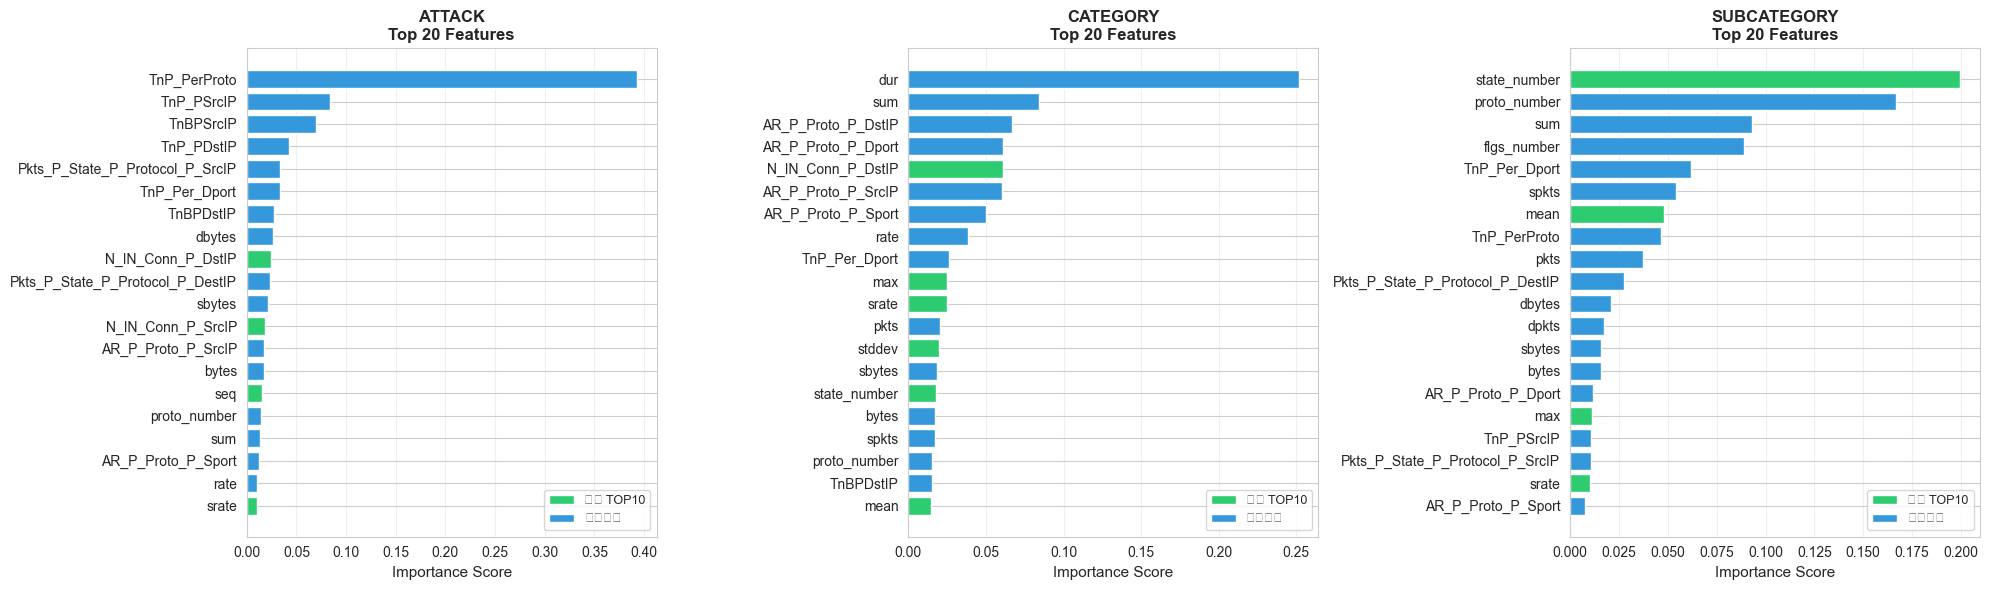


XGBoost 特徵重要性視覺化


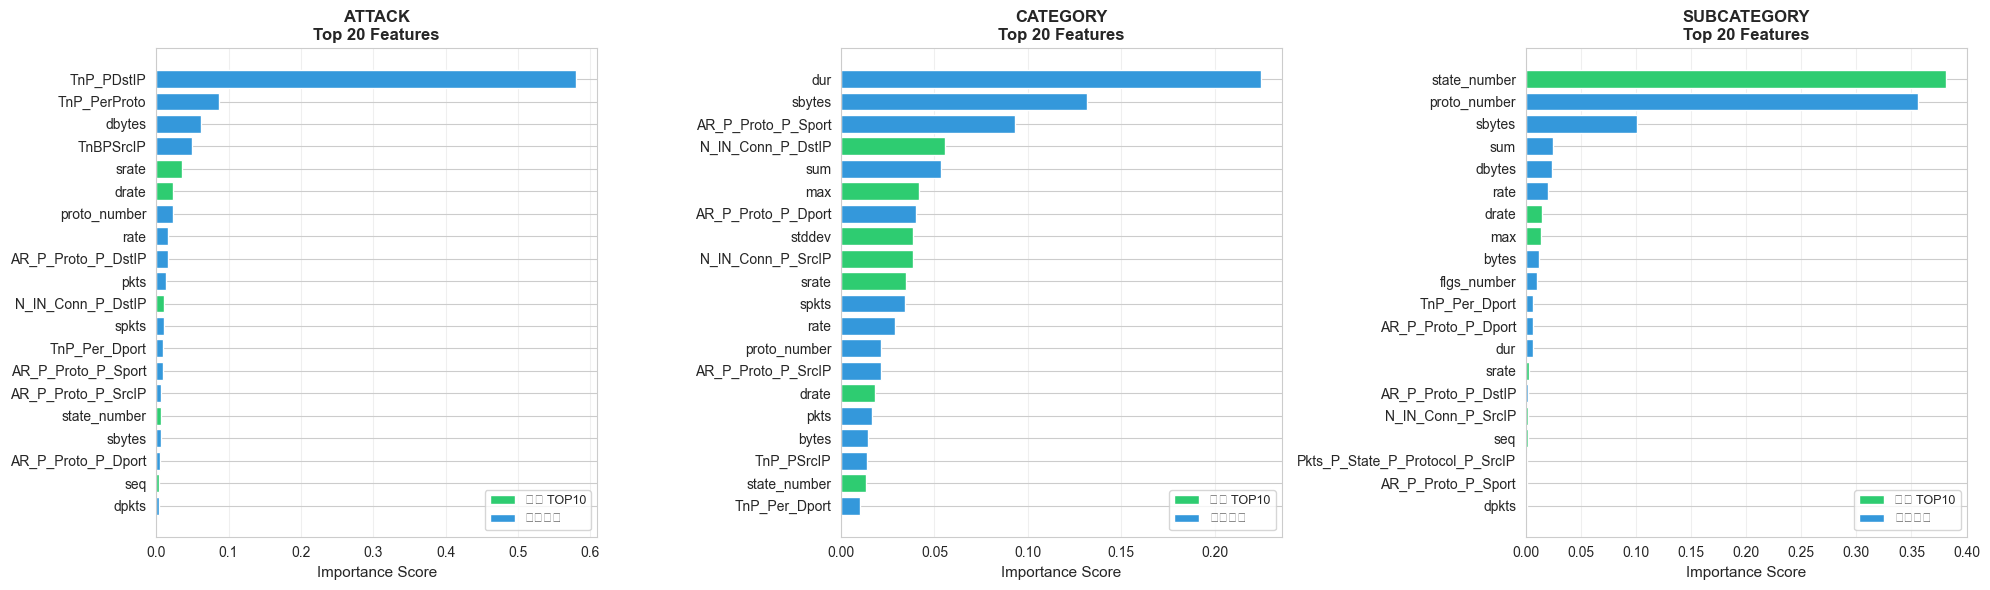


驗證結論

Random Forest:
  • attack: TOP10 特徵中有 10/10 個在全特徵排名中，平均排名 22.2
  • category: TOP10 特徵中有 10/10 個在全特徵排名中，平均排名 18.4
  • subcategory: TOP10 特徵中有 10/10 個在全特徵排名中，平均排名 22.1

XGBoost:
  • attack: TOP10 特徵中有 10/10 個在全特徵排名中，平均排名 19.6
  • category: TOP10 特徵中有 10/10 個在全特徵排名中，平均排名 14.5
  • subcategory: TOP10 特徵中有 10/10 個在全特徵排名中，平均排名 17.2


In [15]:
def plot_feature_importance_comparison(importance_data, target_columns, top_n=15):
    """
    繪製特徵重要性柱狀圖，TOP10特徵用不同顏色標記
    """
    top10_features = {
        "seq", "stddev", "N_IN_Conn_P_SrcIP", "min", "state_number",
        "mean", "N_IN_Conn_P_DstIP", "drate", "srate", "max"
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for idx, target_col in enumerate(target_columns):
        df = importance_data[target_col].head(top_n).copy()
        df['color'] = df['feature'].apply(lambda x: '#2ecc71' if x in top10_features else '#3498db')
        
        ax = axes[idx]
        bars = ax.barh(range(len(df)), df['importance'], color=df['color'].values)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df['feature'])
        ax.set_xlabel('Importance Score', fontsize=11)
        ax.set_title(f'{target_col.upper()}\nTop {top_n} Features', fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        
        # 添加圖例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#2ecc71', label='論文 TOP10'),
            Patch(facecolor='#3498db', label='其他特徵')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

print("\nRandom Forest 特徵重要性視覺化")
plot_feature_importance_comparison(rf_importance, TARGET_COLUMNS, top_n=20)

print("\nXGBoost 特徵重要性視覺化")
plot_feature_importance_comparison(xgb_importance, TARGET_COLUMNS, top_n=20)

print("\n" + "="*80)
print("驗證結論")
print("="*80)

top10_features = {
    "seq", "stddev", "N_IN_Conn_P_SrcIP", "min", "state_number",
    "mean", "N_IN_Conn_P_DstIP", "drate", "srate", "max"
}

for model_name, importance_data in [("Random Forest", rf_importance), ("XGBoost", xgb_importance)]:
    print(f"\n{model_name}:")
    for target_col in TARGET_COLUMNS:
        df = importance_data[target_col]
        top10_count = df[df['feature'].isin(top10_features)].shape[0]
        avg_rank_of_top10 = df[df['feature'].isin(top10_features)]['rank'].mean()
        print(f"  • {target_col}: TOP10 特徵中有 {top10_count}/10 個在全特徵排名中，平均排名 {avg_rank_of_top10:.1f}")


,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
9,attack,0.999993,0.989581,0.987045,0.999993,DecisionTreeGini,71.60
12,attack,0.999993,0.979166,0.986771,0.999993,XGBoost,25.54
0,attack,0.999989,0.958333,0.978258,0.999989,RandomForest,175.35
6,attack,0.999986,0.973955,0.973955,0.999986,DecisionTreeEntropy,28.66
3,attack,0.999253,0.911096,0.611711,0.999525,NaiveBayes,1.61
7,category,0.999928,0.989461,0.992466,0.999928,DecisionTreeEntropy,68.06
1,category,0.999872,0.980354,0.988800,0.999872,RandomForest,180.59
10,category,0.998433,0.982459,0.988457,0.998432,DecisionTreeGini,84.77
13,category,0.999985,0.980392,0.981411,0.999985,XGBoost,137.95
4,category,0.726105,0.804692,0.674839,0.705943,NaiveBayes,1.73


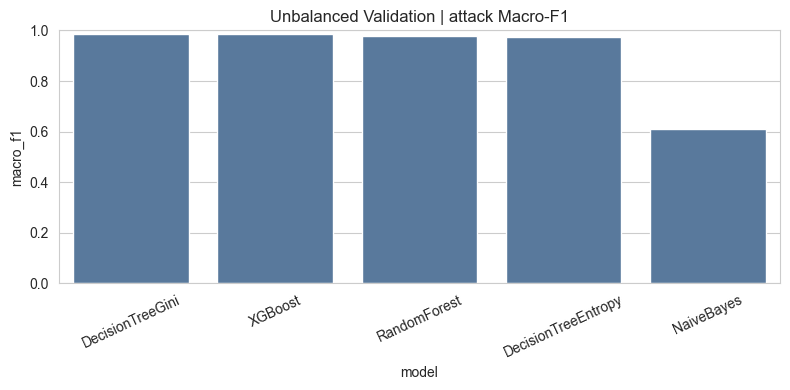

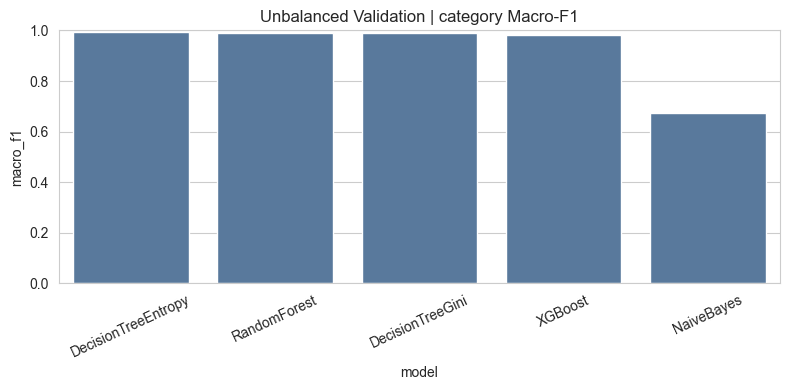

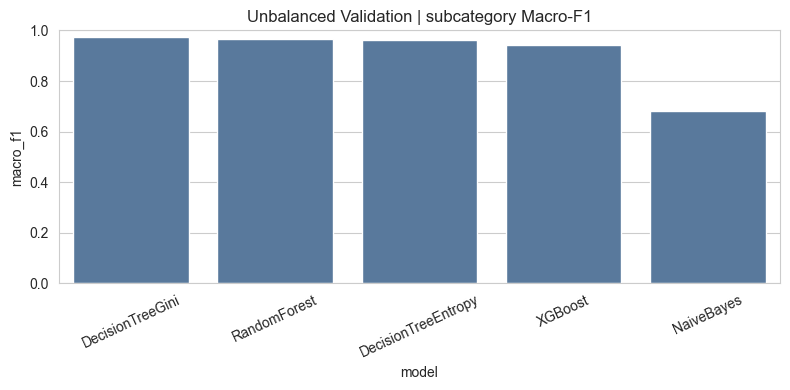

Unbalanced Validation 各目標最佳模型： {'attack': 'DecisionTreeGini', 'category': 'DecisionTreeEntropy', 'subcategory': 'DecisionTreeGini'}


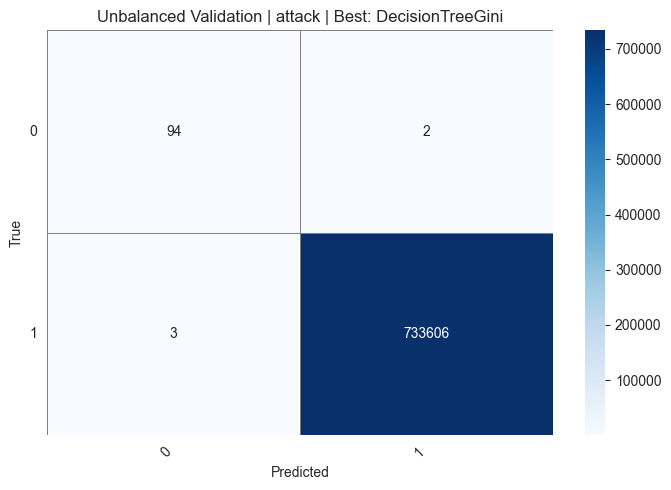

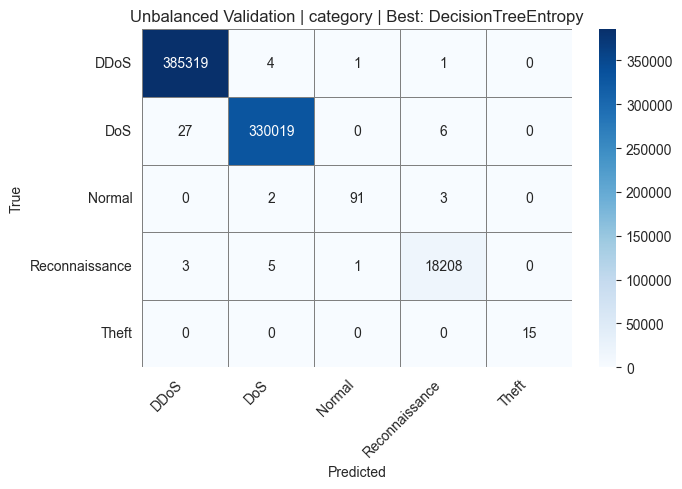

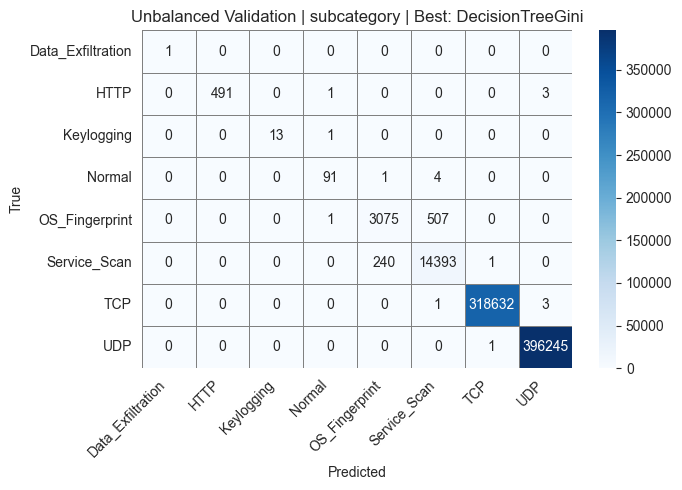

Detailed report (validation) for XGBoost / category:


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    385325
           1       1.00      1.00      1.00    330052
           2       0.98      0.97      0.97        96
           3       1.00      1.00      1.00     18217
           4       0.93      0.93      0.93        15

    accuracy                           1.00    733705
   macro avg       0.98      0.98      0.98    733705
weighted avg       1.00      1.00      1.00    733705



In [16]:
unbalanced_metrics_df = pd.concat([v["metrics"] for v in independent_results.values()], ignore_index=True)
display(unbalanced_metrics_df.sort_values(["target", "macro_f1"], ascending=[True, False]))

show_metric_bars(unbalanced_metrics_df, "Unbalanced Validation")
show_confusion_matrices(independent_results, y_valid, "Unbalanced Validation")

print("Detailed report (validation) for XGBoost / category:")
print(classification_report(y_valid["category"], independent_results["XGBoost"]["preds"]["category"], zero_division=0))

# 下半部：原始資料（不做 Data Balance）(Chain)

這一段先建立基準結果，模擬『不考慮資料平衡』的傳統分類流程。且樹的預測之間獨立
- X -> predict[attack]
- X + predict[attack] -> predict[category_model]
- X + predict[attack] + predict[category_model] -> [subcategory]

## 共用函式（訓練、評估、視覺化）

In [17]:
class ChainedMultiTargetClassifier:
    def __init__(self, attack_model, category_model, subcategory_model):
        self.attack_model = attack_model
        self.category_model = category_model
        self.subcategory_model = subcategory_model

    def fit(self, X, y):
        self.attack_model.fit(X, y["attack"])
        category_features = np.concatenate([X, y[["attack"]].to_numpy()], axis=1)
        self.category_model.fit(category_features, y["category"])
        subcategory_features = np.concatenate([category_features, y[["category"]].to_numpy()], axis=1)
        self.subcategory_model.fit(subcategory_features, y["subcategory"])
        return self

    def predict(self, X):
        pred_attack = self.attack_model.predict(X)
        category_features = np.concatenate([X, pred_attack.reshape(-1, 1)], axis=1)
        pred_category = self.category_model.predict(category_features)
        subcategory_features = np.concatenate([category_features, pred_category.reshape(-1, 1)], axis=1)
        pred_subcategory = self.subcategory_model.predict(subcategory_features)
        return pd.DataFrame({
            "attack": pred_attack,
            "category": pred_category,
            "subcategory": pred_subcategory,
        })

def build_chain_model(model_name, seed=RANDOM_STATE):
    n_category = y_all["category"].nunique()
    n_subcategory = y_all["subcategory"].nunique()

    if model_name == "RandomForest":
        return ChainedMultiTargetClassifier(
            RandomForestClassifier(max_depth=8, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=10, n_estimators=120, random_state=seed, n_jobs=-1),
            RandomForestClassifier(max_depth=12, n_estimators=120, random_state=seed, n_jobs=-1),
        )

    if model_name == "NaiveBayes":
        return ChainedMultiTargetClassifier(GaussianNB(), GaussianNB(), GaussianNB())

    if model_name == "DecisionTreeEntropy":
        return ChainedMultiTargetClassifier(
            DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="entropy", max_depth=12, random_state=seed),
        )

    if model_name == "DecisionTreeGini":
        return ChainedMultiTargetClassifier(
            DecisionTreeClassifier(criterion="gini", max_depth=8, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=seed),
            DecisionTreeClassifier(criterion="gini", max_depth=12, random_state=seed),
        )

    if model_name == "XGBoost":
        return ChainedMultiTargetClassifier(
            XGBClassifier(
                objective="binary:logistic",
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="logloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_category,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
            XGBClassifier(
                objective="multi:softmax",
                num_class=n_subcategory,
                n_estimators=150,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=seed,
                eval_metric="mlogloss",
                n_jobs=-1,
            ),
        )

    raise ValueError(f"Unknown model: {model_name}")

def evaluate_predictions(y_true, y_pred, target_col):
    y_t = y_true[target_col]
    y_p = y_pred[target_col]
    return {
        "target": target_col,
        "accuracy": accuracy_score(y_t, y_p),
        "balanced_accuracy": balanced_accuracy_score(y_t, y_p),
        "macro_f1": f1_score(y_t, y_p, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_t, y_p, average="weighted", zero_division=0),
    }

def run_chain_model(model_name, X_fit, y_fit, X_eval, y_eval):
    import time
    model = build_chain_model(model_name)

    # Chain 模型依序訓練，分開計時
    t0 = time.time()
    model.attack_model.fit(X_fit, y_fit["attack"])
    time_attack = round(time.time() - t0, 2)

    t0 = time.time()
    category_features = np.concatenate([X_fit, y_fit[["attack"]].to_numpy()], axis=1)
    model.category_model.fit(category_features, y_fit["category"])
    time_category = round(time.time() - t0, 2)

    t0 = time.time()
    subcategory_features = np.concatenate([category_features, y_fit[["category"]].to_numpy()], axis=1)
    model.subcategory_model.fit(subcategory_features, y_fit["subcategory"])
    time_subcategory = round(time.time() - t0, 2)

    time_map = {
        "attack": time_attack,
        "category": time_category,
        "subcategory": time_subcategory,
    }

    preds = model.predict(X_eval)

    rows = []
    for target_col in TARGET_COLUMNS:
        row = evaluate_predictions(y_eval, preds, target_col)
        row["model"] = model_name
        row["train_time_sec"] = time_map[target_col]
        rows.append(row)

    return model, preds, pd.DataFrame(rows)

def decode_labels_if_needed(values, target_col):
    if target_col in label_encoders:
        return label_encoders[target_col].inverse_transform(values)
    return values

def show_confusion_matrices(result_store, y_true, section_title):
    metrics_df = pd.concat([v["metrics"] for v in result_store.values()], ignore_index=True)

    best_map = {}
    for target_col in TARGET_COLUMNS:
        picked = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False).iloc[0]
        best_map[target_col] = picked["model"]

    print(f"{section_title} 各目標最佳模型：", best_map)

    for target_col in TARGET_COLUMNS:
        best_model = best_map[target_col]
        y_t = y_true[target_col].to_numpy()
        y_p = result_store[best_model]["preds"][target_col].to_numpy()

        labels = np.unique(np.concatenate([y_t, y_p]))
        cm = confusion_matrix(y_t, y_p, labels=labels)

        tick_labels = decode_labels_if_needed(labels, target_col)

        plt.figure(figsize=(7, 5))
        sns.heatmap(
            cm,
            cmap="Blues",
            annot=True,
            fmt="d",
            linewidths=0.5,
            linecolor="gray"
        )
        plt.title(f"{section_title} | {target_col} | Best: {best_model}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.xticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=45, ha="right")
        plt.yticks(np.arange(len(tick_labels)) + 0.5, tick_labels, rotation=0)
        plt.tight_layout()
        plt.show()

def show_metric_bars(metrics_df, title_prefix):
    for target_col in TARGET_COLUMNS:
        sub_df = metrics_df[metrics_df["target"] == target_col].sort_values("macro_f1", ascending=False)
        plt.figure(figsize=(8, 4))
        sns.barplot(data=sub_df, x="model", y="macro_f1", color="#4E79A7")
        plt.ylim(0, 1)
        plt.title(f"{title_prefix} | {target_col} Macro-F1")
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

def build_attack_model(model_name, seed=RANDOM_STATE):
    if model_name == "RandomForest":
        return RandomForestClassifier(max_depth=8, n_estimators=120, random_state=seed, n_jobs=-1)
    if model_name == "NaiveBayes":
        return GaussianNB()
    if model_name == "DecisionTreeEntropy":
        return DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=seed)
    if model_name == "DecisionTreeGini":
        return DecisionTreeClassifier(criterion="gini", max_depth=8, random_state=seed)
    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            n_estimators=120,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {model_name}")

def run_attack_cv(X, y_attack, model_names, folds=5, sample_size=120000):
    sample_size = min(sample_size, len(y_attack))
    idx = np.random.RandomState(RANDOM_STATE).choice(len(y_attack), size=sample_size, replace=False)
    X_sub = X[idx]
    y_sub = y_attack.iloc[idx].to_numpy()

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for name in model_names:
        est = build_attack_model(name)
        scores = cross_validate(
            est,
            X_sub,
            y_sub,
            cv=skf,
            scoring={
                "acc": "accuracy",
                "bacc": "balanced_accuracy",
                "f1_macro": "f1_macro",
            },
            n_jobs=1,
            return_train_score=False,
        )

        rows.append({
            "model": name,
            "folds": folds,
            "sample_size": sample_size,
            "cv_accuracy_mean": scores["test_acc"].mean(),
            "cv_balanced_accuracy_mean": scores["test_bacc"].mean(),
            "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
        })

    return pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)

### 分類法 1：Random Forest
- 用途：透過多棵樹集成，降低單一決策樹過擬合風險
- 參數：`max_depth=[8,10,12]`、`n_estimators=120`、`random_state=42`

In [18]:
chain_results = {}

rf_model, rf_preds, rf_metrics = run_chain_model("RandomForest", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["RandomForest"] = {"model": rf_model, "preds": rf_preds, "metrics": rf_metrics}
rf_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999985,0.942708,0.969610,0.999985,RandomForest,161.28
1,category,0.999812,0.972010,0.985403,0.999812,RandomForest,187.21
2,subcategory,0.999184,0.963391,0.977296,0.999162,RandomForest,148.37


### 分類法 2：Naive Bayes
- 用途：速度快、可做機率式分類基準
- 參數：`GaussianNB()`（使用預設參數）

In [19]:
nb_model, nb_preds, nb_metrics = run_chain_model("NaiveBayes", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["NaiveBayes"] = {"model": nb_model, "preds": nb_preds, "metrics": nb_metrics}
nb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999253,0.911096,0.611711,0.999525,NaiveBayes,1.64
1,category,0.725645,0.737087,0.641781,0.705662,NaiveBayes,1.98
2,subcategory,0.985177,0.709940,0.535357,0.985389,NaiveBayes,2.04


### 分類法 3：Decision Tree (Entropy)
- 用途：資訊增益（Entropy）切分規則
- 參數：`criterion=entropy`、`max_depth=[8,10,12]`

In [20]:
dt_e_model, dt_e_preds, dt_e_metrics = run_chain_model("DecisionTreeEntropy", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["DecisionTreeEntropy"] = {"model": dt_e_model, "preds": dt_e_preds, "metrics": dt_e_metrics}
dt_e_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999986,0.973955,0.973955,0.999986,DecisionTreeEntropy,29.30
1,category,0.999929,0.976119,0.982556,0.999929,DecisionTreeEntropy,66.15
2,subcategory,0.999400,0.965207,0.931747,0.999402,DecisionTreeEntropy,35.08


### 分類法 4：Decision Tree (Gini)
- 用途：Gini impurity 切分規則
- 參數：`criterion=gini`、`max_depth=[8,10,12]`

In [21]:
dt_g_model, dt_g_preds, dt_g_metrics = run_chain_model("DecisionTreeGini", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["DecisionTreeGini"] = {"model": dt_g_model, "preds": dt_g_preds, "metrics": dt_g_metrics}
dt_g_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999995,0.994790,0.989689,0.999995,DecisionTreeGini,65.12
1,category,0.998441,0.979564,0.986097,0.998441,DecisionTreeGini,89.96
2,subcategory,0.999614,0.978789,0.983860,0.999613,DecisionTreeGini,29.21


### 分類法 5：XGBoost
- 用途：梯度提升樹，通常在結構化資料有較好表現
- 參數：`n_estimators=150`、`max_depth=6`、`learning_rate=0.08`、`subsample=0.8`、`colsample_bytree=0.8`

In [22]:
xgb_model, xgb_preds, xgb_metrics = run_chain_model("XGBoost", X_train_scaled, y_train, X_valid_scaled, y_valid)
chain_results["XGBoost"] = {"model": xgb_model, "preds": xgb_preds, "metrics": xgb_metrics}
xgb_metrics

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
0,attack,0.999993,0.979166,0.986771,0.999993,XGBoost,20.58
1,category,0.999978,0.978306,0.975326,0.999978,XGBoost,108.03
2,subcategory,0.999535,0.976681,0.976107,0.999533,XGBoost,163.79


### 原始資料結果整理 + 視覺化結果1
- 顯示各模型指標表
- 畫出 Macro-F1 條圖
- 顯示每個目標最佳模型的混淆矩陣

,target,accuracy,balanced_accuracy,macro_f1,weighted_f1,model,train_time_sec
9,attack,0.999995,0.994790,0.989689,0.999995,DecisionTreeGini,65.12
12,attack,0.999993,0.979166,0.986771,0.999993,XGBoost,20.58
6,attack,0.999986,0.973955,0.973955,0.999986,DecisionTreeEntropy,29.30
0,attack,0.999985,0.942708,0.969610,0.999985,RandomForest,161.28
3,attack,0.999253,0.911096,0.611711,0.999525,NaiveBayes,1.64
10,category,0.998441,0.979564,0.986097,0.998441,DecisionTreeGini,89.96
1,category,0.999812,0.972010,0.985403,0.999812,RandomForest,187.21
7,category,0.999929,0.976119,0.982556,0.999929,DecisionTreeEntropy,66.15
13,category,0.999978,0.978306,0.975326,0.999978,XGBoost,108.03
4,category,0.725645,0.737087,0.641781,0.705662,NaiveBayes,1.98


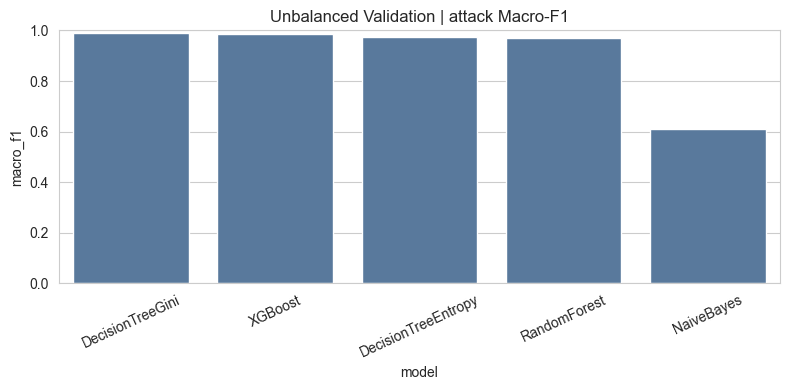

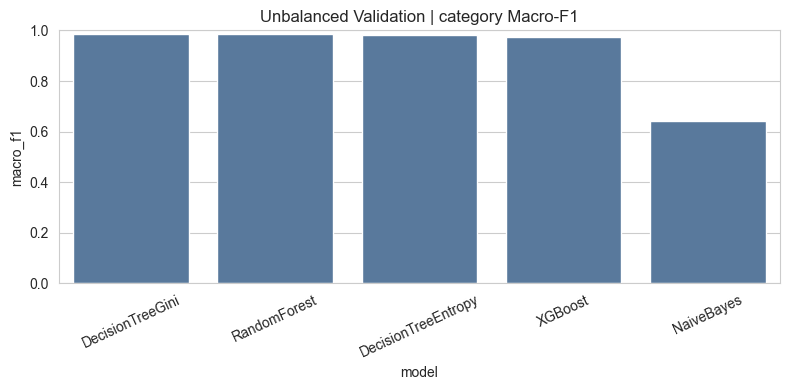

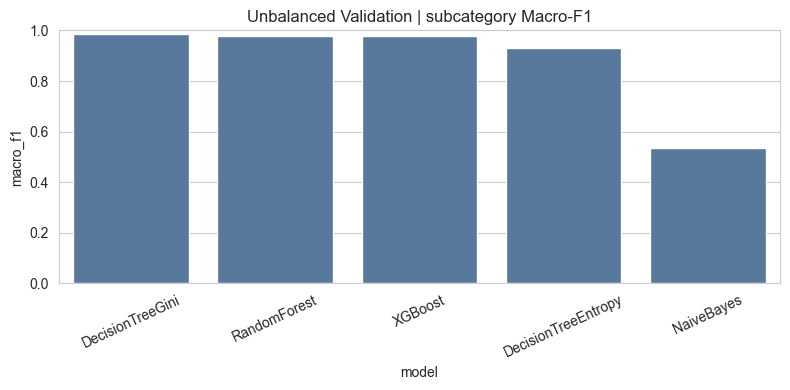

Unbalanced Validation 各目標最佳模型： {'attack': 'DecisionTreeGini', 'category': 'DecisionTreeGini', 'subcategory': 'DecisionTreeGini'}


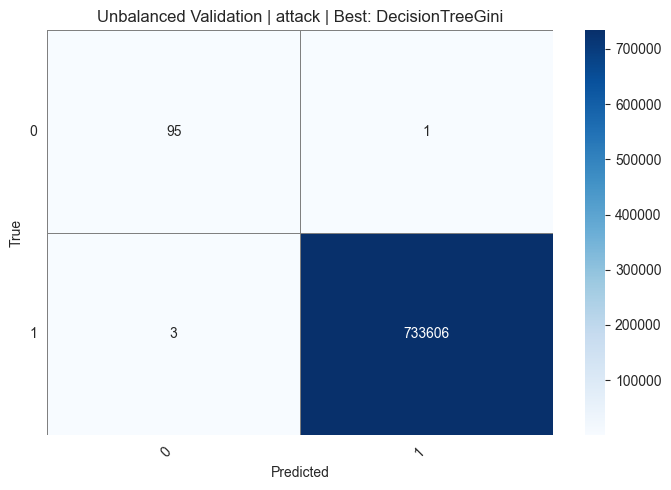

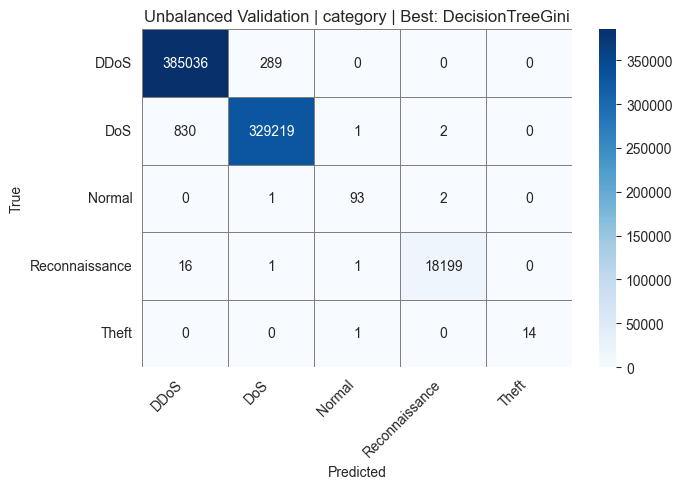

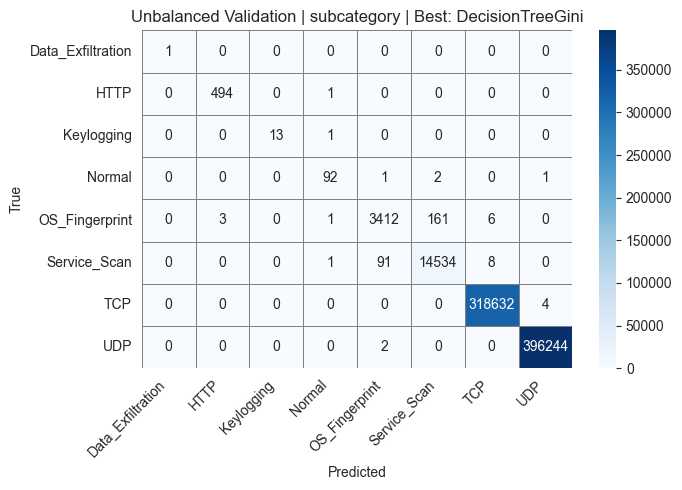

Detailed report (validation) for XGBoost / category:


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    385325
           1       1.00      1.00      1.00    330052
           2       0.99      0.96      0.97        96
           3       1.00      1.00      1.00     18217
           4       0.88      0.93      0.90        15

    accuracy                           1.00    733705
   macro avg       0.97      0.98      0.98    733705
weighted avg       1.00      1.00      1.00    733705



In [23]:
unbalanced_metrics_df = pd.concat([v["metrics"] for v in chain_results.values()], ignore_index=True)
display(unbalanced_metrics_df.sort_values(["target", "macro_f1"], ascending=[True, False]))

show_metric_bars(unbalanced_metrics_df, "Unbalanced Validation")
show_confusion_matrices(chain_results, y_valid, "Unbalanced Validation")

print("Detailed report (validation) for XGBoost / category:")
print(classification_report(y_valid["category"], chain_results["XGBoost"]["preds"]["category"], zero_division=0))